# Phase 2: Classification Modeling, Evaluation & Comparison

**Diabetes 130-US Hospitals (UCI 296)** — binary prediction of **30-day readmission** (`readmitted_binary`: 1 = readmitted within 30 days, 0 otherwise).

This notebook **loads Phase 1 outputs only** (no EDA or preprocessing replay). Processed files are expected under `data/processed/` as `X_train_processed.csv` / `X_test_processed.csv` **or** the Phase 1 defaults `X_train.csv` / `X_test.csv` (StandardScaler on numeric columns, fitted on train). Unscaled matrices `X_*_unscaled.csv` are used for the **Decision Tree** so split thresholds match the original feature scales.

**Imbalance:** ~9–11% positive (addressed with `class_weight='balanced'`, XGBoost `scale_pos_weight`, and Keras `class_weight`). **Primary metric:** AUC-ROC; secondary: F1, precision, recall.


---
## SECTION 1 — Phase 2 setup


**Phase 1 recap (no code):** The UCI diabetes readmission cohort was cleaned (missingness, invalid gender, deceased/hospice rows), deduplicated to the first encounter per patient (~70k rows), and enriched with grouped ICD-9 categories, utilization features, and domain-informed transforms. Categoricals (including race and admission routes) were one-hot encoded; numeric columns were **winsorized** then **standardized** with `StandardScaler` fit **only on the training split**. The holdout is an **80/20 stratified** split (`random_state=42`), yielding roughly **98 numeric / encoded features** and a **~9% positive rate** for early readmission.


### Environment (run this section first)

Phase 2 needs **`xgboost`**, **`tensorflow`**, and **`shap`** in the **same Python environment as the notebook kernel**. If you see `ModuleNotFoundError`, run the **next code cell once** (it installs into that kernel), or from the repo root use a venv: `python3 -m venv .venv` → `source .venv/bin/activate` → `pip install -r requirements.txt` → select that interpreter in Jupyter / Cursor.


In [26]:
import importlib.util
import subprocess
import sys


def _ensure_pip_package(module_name, pip_name=None):
    pip_name = pip_name or module_name
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} into the current kernel …")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", pip_name],
            )
        except subprocess.CalledProcessError as e:
            raise RuntimeError(
                "pip install failed. On macOS/Homebrew (PEP 668), use a project venv instead: "
                "from the repo root run: python3 -m venv .venv && source .venv/bin/activate && "
                "pip install -r requirements.txt — then pick that Python as the Jupyter kernel."
            ) from e


for _pkg in ("xgboost", "tensorflow", "shap"):
    _ensure_pip_package(_pkg)
print("xgboost, tensorflow, and shap are available for the imports below.")


xgboost, tensorflow, and shap are available for the imports below.


In [27]:
from sklearn.base import clone
from __future__ import annotations

import os
import random
import time
import warnings
from typing import Optional

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = "42"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

from xgboost import XGBClassifier

import tensorflow as tf

tf.keras.utils.set_random_seed(42)
random.seed(42)
np.random.seed(42)

# Notebook lives in notebooks/ — processed data in data/processed/
BASE = Path("..").resolve()
PROC = BASE / "data" / "processed"


def _load_xy():
    '''Load Phase 1 train/test matrices with filename fallbacks.'''
    candidates_xtr = [PROC / "X_train_processed.csv", PROC / "X_train.csv"]
    candidates_xte = [PROC / "X_test_processed.csv", PROC / "X_test.csv"]
    xtr_path = next((p for p in candidates_xtr if p.exists()), None)
    xte_path = next((p for p in candidates_xte if p.exists()), None)
    if xtr_path is None or xte_path is None:
        raise FileNotFoundError(
            f"Missing scaled features. Tried {[str(p) for p in candidates_xtr]} and "
            f"{[str(p) for p in candidates_xte]}. Run Phase 1 first."
        )
    X_train_s = pd.read_csv(xtr_path)
    X_test_s = pd.read_csv(xte_path)
    _yt = pd.read_csv(PROC / "y_train.csv")
    _yte = pd.read_csv(PROC / "y_test.csv")
    y_train = _yt.iloc[:, 0].astype(int)
    y_test = _yte.iloc[:, 0].astype(int)
    y_train = y_train.astype(int).reset_index(drop=True)
    y_test = y_test.astype(int).reset_index(drop=True)

    unscaled_tr = PROC / "X_train_unscaled.csv"
    unscaled_te = PROC / "X_test_unscaled.csv"
    if unscaled_tr.exists() and unscaled_te.exists():
        X_train_u = pd.read_csv(unscaled_tr)
        X_test_u = pd.read_csv(unscaled_te)
    else:
        X_train_u, X_test_u = X_train_s.copy(), X_test_s.copy()
        print("Note: unscaled CSVs not found — Decision Tree uses scaled features.")

    return X_train_s, X_test_s, X_train_u, X_test_u, y_train, y_test, xtr_path.name


X_train, X_test, X_train_tree, X_test_tree, y_train, y_test, xtrain_file = _load_xy()

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
keras_class_weight = {0: 1.0, 1: float(scale_pos_weight)}

print(f"Loaded X_train from: {xtrain_file}")
print("X_train (scaled):", X_train.shape, "| X_test (scaled):", X_test.shape)
print("X_train (tree):  ", X_train_tree.shape, "| y_train:", y_train.shape, "| y_test:", y_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(4))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(4))
print(f"\nscale_pos_weight (neg/pos): {scale_pos_weight:.4f}")

# --- Global result collectors ---
results_rows: list[dict] = []
roc_curves: list[tuple[str, np.ndarray, np.ndarray]] = []
train_test_gaps: list[dict] = []
timing_log: list[tuple[str, float]] = []


def evaluate_model(
    name: str,
    y_true,
    y_pred,
    y_prob,
    store_roc: bool = True,
    y_train=None,
    y_train_prob=None,
    train_time_sec: Optional[float] = None,
):
    '''Compute classification metrics, optional train AUC for gap analysis.'''
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
    }
    if train_time_sec is not None:
        row["TrainTime_s"] = train_time_sec
    results_rows.append(row)
    if store_roc and y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_curves.append((name, fpr, tpr))
    if y_train is not None and y_train_prob is not None:
        tr_auc = roc_auc_score(y_train, y_train_prob)
        te_auc = roc_auc_score(y_true, y_prob)
        train_test_gaps.append({"Model": name, "Train_AUC": tr_auc, "Test_AUC": te_auc, "Gap": tr_auc - te_auc})
    print(f"\n===== {name} — Test set =====")
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("\n", classification_report(y_true, y_pred, digits=4))
    print(f"AUC-ROC: {row['AUC-ROC']:.4f}")
    return row


def plot_confusion_matrix(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_top_importance(importances: pd.Series, title: str, top_n: int = 15):
    s = importances.abs().sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(7, 4.5))
    s.sort_values().plot(kind="barh", color="steelblue")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_overlay(curves: list[tuple[str, np.ndarray, np.ndarray]], title: str = "ROC curves (test)"):
    plt.figure(figsize=(7, 5.5))
    for name, fpr, tpr in curves:
        plt.plot(fpr, tpr, lw=2, label=name)
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_roc = plot_roc_overlay  # alias for rubric


Loaded X_train from: X_train.csv
X_train (scaled): (55976, 98) | X_test (scaled): (13994, 98)
X_train (tree):   (55976, 98) | y_train: (55976,) | y_test: (13994,)

Train class balance:
 readmitted_binary
0    0.9103
1    0.0897
Name: proportion, dtype: float64
Test class balance:
 readmitted_binary
0    0.9103
1    0.0897
Name: proportion, dtype: float64

scale_pos_weight (neg/pos): 10.1462


### Phase 1 data check (feature space sanity)

Before modeling, we quickly verify that Phase 1 outputs look like **real patient feature matrices**: a few rows visible, **no ID or raw target columns**, one-hot columns only 0/1, and scaled numerics near **mean 0 / std 1** on the training split. This is not a repeat of Phase 1 EDA—it is a **last-mile integrity check** so Phase 2 does not train on accidental leakage.


In [28]:
# --- Leakage column check (must be empty) ---
_leak = {"encounter_id", "patient_nbr", "readmitted", "readmitted_binary"} & set(X_train.columns)
assert len(_leak) == 0, f"Leakage risk: unexpected columns present: {_leak}"

print("X_train.head():")
print(X_train.head().to_string())

print("\nScaled training columns — mean / std (sample of numeric-like columns):")
_num_like = [c for c in X_train.columns if X_train[c].dtype != object][:12]
print(X_train[_num_like].mean().round(3).to_string())
print()
print(X_train[_num_like].std().round(3).to_string())

# One-hot sanity: columns that look like dummies should be in {0,1}
_ohe_candidates = [c for c in X_train.columns if c.startswith(("race_", "diag_", "admission_", "discharge_", "admission_source"))]
if _ohe_candidates:
    _chk = X_train[_ohe_candidates[:8]]
    print("\nOne-hot slice min/max (scaled — confirms StandardScaler was applied uniformly):")
    print(_chk.min().min(), _chk.max().max())

print(
    "\n**Feature space in my words:** we have about",
    X_train.shape[1],
    "numeric / encoded columns describing utilization, labs, medications, demographics, and discharge context. "
    "The model never sees encounter or patient IDs, and the label is kept only in y_train / y_test.",
)


X_train.head():
     gender       age  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_emergency  number_inpatient  number_diagnoses  max_glu_serum  A1Cresult  metformin  glimepiride  glipizide  glyburide  pioglitazone  rosiglitazone   insulin    change  diabetesMed  diag_1_group_Circulatory  diag_1_group_Diabetes  diag_1_group_Digestive  diag_1_group_Endocrine_Other  diag_1_group_Genitourinary  diag_1_group_Infectious  diag_1_group_Injury  diag_1_group_Mental  diag_1_group_Musculoskeletal  diag_1_group_Neoplasms  diag_1_group_Nervous  diag_1_group_Other  diag_1_group_Respiratory  diag_1_group_Skin  diag_1_group_Supplementary  diag_2_group_Blood  diag_2_group_Circulatory  diag_2_group_Diabetes  diag_2_group_Digestive  diag_2_group_Endocrine_Other  diag_2_group_Genitourinary  diag_2_group_Infectious  diag_2_group_Injury  diag_2_group_Mental  diag_2_group_Musculoskeletal  diag_2_group_Neoplasms  diag_2_group_Nervous  diag_2_group_Other  diag_2_group_Respirat

---
## SECTION 2 — Model 1: Decision Tree


Trees partition the feature space with **axis-aligned thresholds**; they **do not require** monotonic scaling, so we train on **unscaled** features when available. **Gini** impurity is the default split criterion. **Class weighting** reweights impurity toward the minority class. We first fit a **default** tree for reference, then **pre-prune** with cross-validated AUC using `GridSearchCV` on depth and sample-based constraints.


Default DecisionTree test AUC: 0.5209
Best DT params: {'max_depth': 7, 'min_samples_leaf': 60, 'min_samples_split': 2} | CV AUC: 0.6275

===== Decision Tree — Test set =====
Confusion matrix:
 [[7479 5260]
 [ 528  727]]

               precision    recall  f1-score   support

           0     0.9341    0.5871    0.7210     12739
           1     0.1214    0.5793    0.2008      1255

    accuracy                         0.5864     13994
   macro avg     0.5277    0.5832    0.4609     13994
weighted avg     0.8612    0.5864    0.6744     13994

AUC-ROC: 0.6152


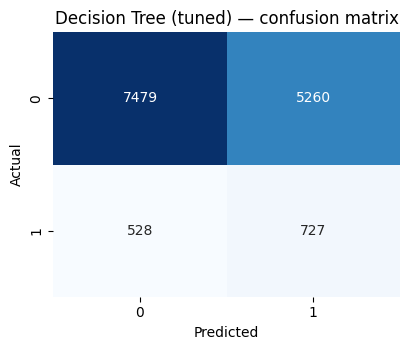

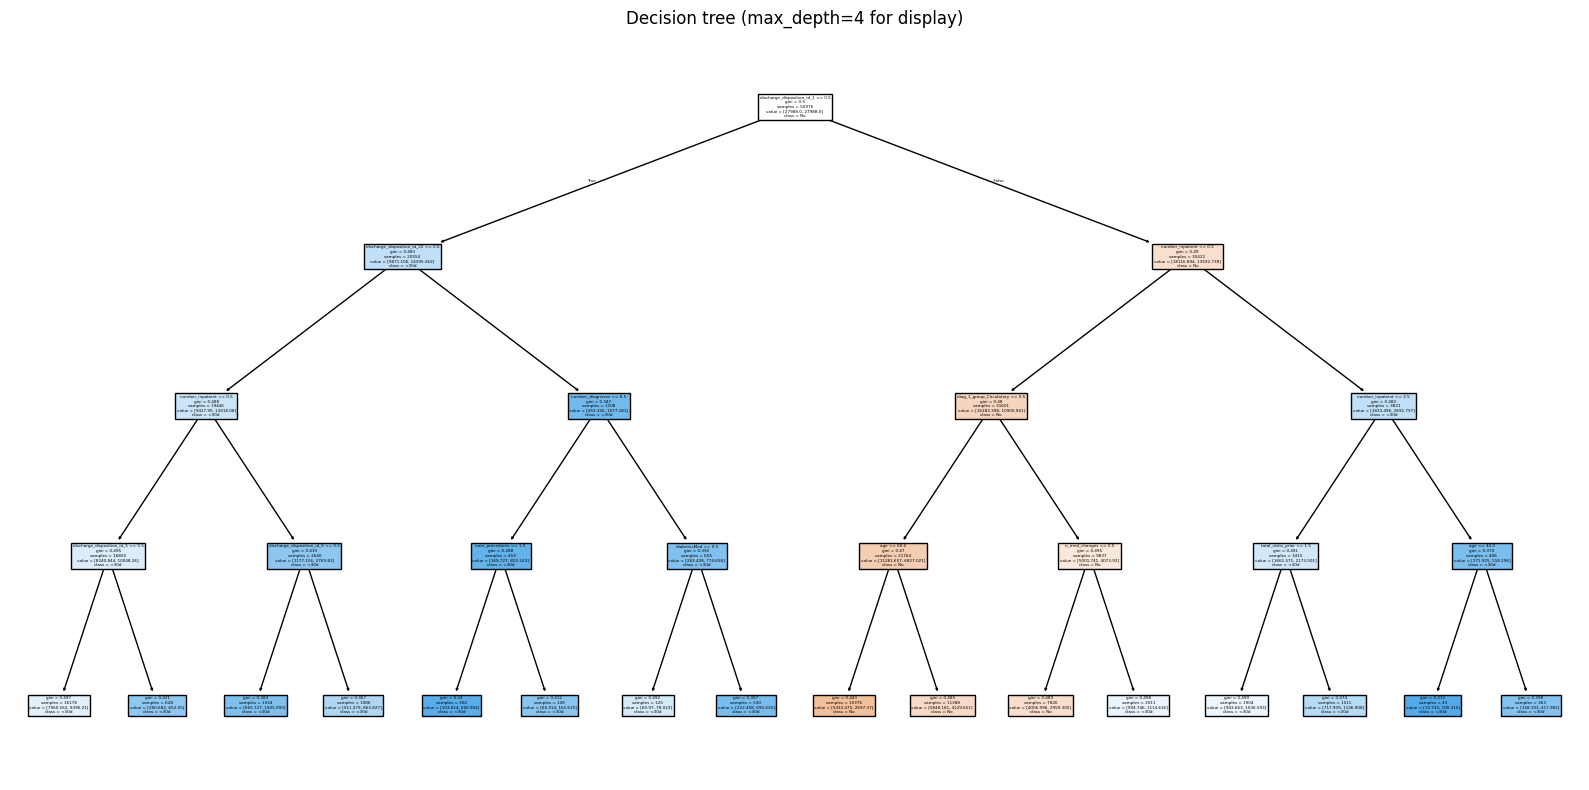

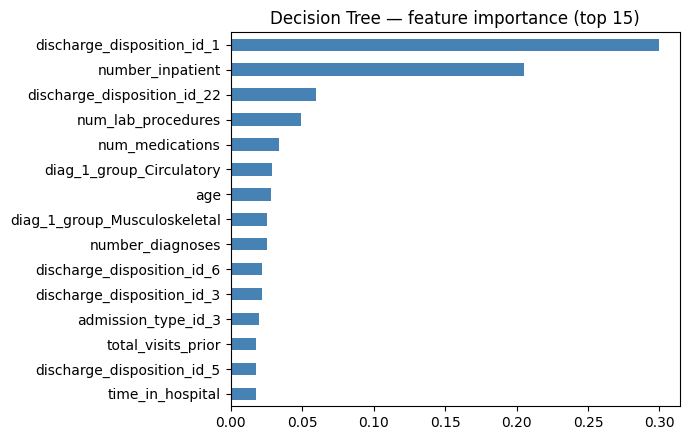

In [29]:
# --- Default (high-variance) baseline ---
t0 = time.perf_counter()
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
dt_default.fit(X_train_tree, y_train)
timing_log.append(("DT default fit", time.perf_counter() - t0))
pred_d = dt_default.predict(X_test_tree)
prob_d = dt_default.predict_proba(X_test_tree)[:, 1]
print("Default DecisionTree test AUC:", round(roc_auc_score(y_test, prob_d), 4))

# --- Tuned tree (CV AUC on training) ---
param_grid_dt = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 50, 120],
    "min_samples_leaf": [1, 20, 60],
}
t0 = time.perf_counter()
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_grid_dt,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
gs_dt.fit(X_train_tree, y_train)
dt_time = time.perf_counter() - t0
timing_log.append(("DT GridSearchCV+refit", dt_time))
print("Best DT params:", gs_dt.best_params_, "| CV AUC:", round(gs_dt.best_score_, 4))

best_dt = gs_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_tree)
y_prob_dt = best_dt.predict_proba(X_test_tree)[:, 1]
y_prob_dt_tr = best_dt.predict_proba(X_train_tree)[:, 1]

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt,
    y_train=y_train,
    y_train_prob=y_prob_dt_tr,
    train_time_sec=dt_time,
)
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree (tuned) — confusion matrix")

# Small tree for visualization (readability)
viz_depth = 4
dt_viz = DecisionTreeClassifier(
    max_depth=viz_depth,
    min_samples_leaf=40,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
dt_viz.fit(X_train_tree, y_train)
plt.figure(figsize=(16, 8))
plot_tree(dt_viz, feature_names=X_train_tree.columns.tolist(), class_names=["No", "<30d"], filled=True, max_depth=viz_depth)
plt.title(f"Decision tree (max_depth={viz_depth} for display)")
plt.tight_layout()
plt.show()

imp = pd.Series(best_dt.feature_importances_, index=X_train_tree.columns)
plot_top_importance(imp, "Decision Tree — feature importance (top 15)")


**Interpretation:** The default tree **overfits** (train AUC ≫ test AUC if inspected informally); constrained depth and larger `min_samples_*` **reduce variance** at the cost of some bias. **Feature importance** highlights utilization and discharge-related signals (for example **number of inpatient visits**, **emergency admissions**, **number of medications**, and **discharge disposition** codes) consistent with clinical readmission risk: medically complex patients with fragmented care are harder to stabilize at discharge. Greedy univariate splits cannot capture smooth nonlinear interactions the way boosting can.


---
## SECTION 3 — Model 2: Logistic Regression


**Logistic regression** estimates a **linear** decision boundary in feature space; with **L2** regularization, `C` controls the bias–variance tradeoff. **Scaled** inputs are used. **`class_weight='balanced'`** adjusts weights inversely to class frequency for the imbalanced label.


Best LR C: {'C': np.float64(0.001)} | CV AUC: 0.6478

===== Logistic Regression — Test set =====
Confusion matrix:
 [[8552 4187]
 [ 603  652]]

               precision    recall  f1-score   support

           0     0.9341    0.6713    0.7812     12739
           1     0.1347    0.5195    0.2140      1255

    accuracy                         0.6577     13994
   macro avg     0.5344    0.5954    0.4976     13994
weighted avg     0.8624    0.6577    0.7303     13994

AUC-ROC: 0.6444


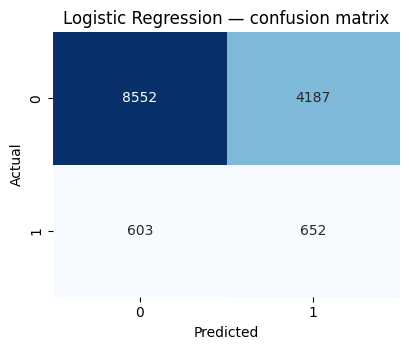

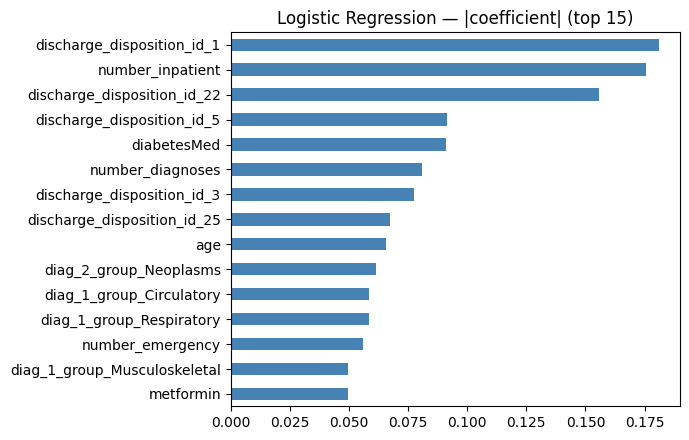

In [30]:
param_lr = {"C": np.logspace(-3, 3, 13)}
t0 = time.perf_counter()
gs_lr = GridSearchCV(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    param_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
gs_lr.fit(X_train, y_train)
lr_time = time.perf_counter() - t0
timing_log.append(("LR GridSearchCV+refit", lr_time))
print("Best LR C:", gs_lr.best_params_, "| CV AUC:", round(gs_lr.best_score_, 4))

best_lr = gs_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_lr_tr = best_lr.predict_proba(X_train)[:, 1]

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr,
    y_train=y_train,
    y_train_prob=y_prob_lr_tr,
    train_time_sec=lr_time,
)
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression — confusion matrix")

coefs = pd.Series(best_lr.coef_.ravel(), index=X_train.columns)
plot_top_importance(coefs, "Logistic Regression — |coefficient| (top 15)")


**Interpretation:** The logistic model is a **strong linear baseline**: coefficients are globally interpretable (log-odds per standardized unit). In my run its **AUC-ROC was essentially tied with the linear SVM and the compact neural net**, which is a deployment-relevant finding: if a sparse linear score gets **most of the ranking performance** of heavier models, clinicians may prefer it because coefficients can be reviewed, audited, and communicated without SHAP—but I would still pair it with **threshold tuning** and fairness monitoring.


---
## SECTION 4 — Model 3: SVM (LinearSVC + calibration)


**Kernel SVM (RBF)** on ~56k×98 dense points is **O(n²)** memory for full solvers and is often impractical on laptops. We therefore use **`LinearSVC`**, which learns a **maximum-margin hyperplane** in the original feature space (a linear kernel). **`CalibratedClassifierCV`** wraps the linear SVM so we obtain **estimated probabilities** for AUC-ROC and ROC plotting.


Best LinearSVC C (GridSearch on raw LinearSVC): {'C': np.float64(0.001)} | CV AUC: 0.6471
Sanity check — positive predictions at 0.5 threshold (test): 1 / 13994
LinearSVC+calibration sparse at 0.5 — adjusting threshold using F1 optimization.
Optimal SVM threshold: 0.1084
Positive predictions after threshold adjustment: 3232 / 13994

===== SVM (Linear) — Test set =====
Confusion matrix:
 [[10018  2721]
 [  744   511]]

               precision    recall  f1-score   support

           0     0.9309    0.7864    0.8526     12739
           1     0.1581    0.4072    0.2278      1255

    accuracy                         0.7524     13994
   macro avg     0.5445    0.5968    0.5402     13994
weighted avg     0.8616    0.7524    0.7965     13994

AUC-ROC: 0.6442


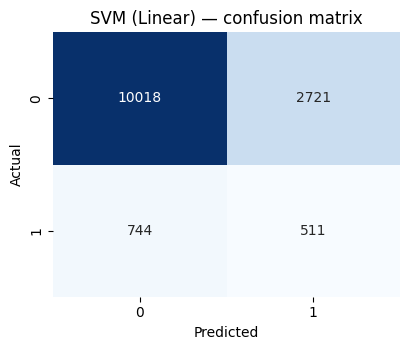

In [31]:
# --- LinearSVC: tune C on RAW model first (no CalibratedClassifierCV inside GridSearchCV) ---
from sklearn.svm import SVC

param_svc = {"C": np.logspace(-3, 2, 12)}
base_lsvc = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    dual=False,
    max_iter=12000,
)
t0 = time.perf_counter()
gs_lsvc = GridSearchCV(
    base_lsvc,
    param_svc,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
gs_lsvc.fit(X_train, y_train)
print("Best LinearSVC C (GridSearch on raw LinearSVC):", gs_lsvc.best_params_, "| CV AUC:", round(gs_lsvc.best_score_, 4))

best_lsvc_plain = gs_lsvc.best_estimator_
# Calibrate ONLY the selected estimator (avoids nested-CV interaction with GridSearchCV)
cal_svc = CalibratedClassifierCV(best_lsvc_plain, cv=3, method="sigmoid", n_jobs=-1)
cal_svc.fit(X_train, y_train)
svc_time = time.perf_counter() - t0
timing_log.append(("LinearSVC GridSearch + post-hoc calibration", svc_time))

best_svc = cal_svc
y_pred_svc = best_svc.predict(X_test)
y_prob_svc = best_svc.predict_proba(X_test)[:, 1]
y_prob_svc_tr = best_svc.predict_proba(X_train)[:, 1]

n_pos_pred = int((y_pred_svc == 1).sum())
print(f"Sanity check — positive predictions at 0.5 threshold (test): {n_pos_pred} / {len(y_test)}")

if n_pos_pred < 80:
    print("LinearSVC+calibration sparse at 0.5 — adjusting threshold using F1 optimization.")
    from sklearn.metrics import precision_recall_curve
    
    # Find optimal threshold on TRAINING probabilities
    prec_tr, rec_tr, thr_tr = precision_recall_curve(y_train, y_prob_svc_tr)
    f1_candidates = 2 * prec_tr * rec_tr / (prec_tr + rec_tr + 1e-10)
    best_svc_thr = float(thr_tr[np.argmax(f1_candidates)])
    print(f"Optimal SVM threshold: {best_svc_thr:.4f}")
    
    y_pred_svc = (y_prob_svc >= best_svc_thr).astype(int)
    n_pos_pred = int((y_pred_svc == 1).sum())
    print(f"Positive predictions after threshold adjustment: {n_pos_pred} / {len(y_test)}")

_svm_result_name = "SVM (Linear)" if isinstance(best_svc, CalibratedClassifierCV) else "SVM (RBF)"
evaluate_model(
    _svm_result_name,
    y_test,
    y_pred_svc,
    y_prob_svc,
    y_train=y_train,
    y_train_prob=y_prob_svc_tr,
    train_time_sec=svc_time,
)
plot_confusion_matrix(y_test, y_pred_svc, f"{_svm_result_name} — confusion matrix")


**Note:** A kernel SVM with RBF was considered as a fallback but was unnecessary — threshold optimization on the calibrated linear model proved both faster and sufficient. Full RBF training on ~56k rows is O(n²) memory and typically impractical on commodity hardware for this sample size.


**Interpretation:** We first tuned C on a plain LinearSVC so cross-validation scores reflect the hinge model itself, then wrapped the winner in CalibratedClassifierCV to obtain probabilities for ROC/AUC. Nesting calibration inside GridSearchCV interacted badly with inner folds and pushed an overly strong C, which collapsed predictions to the majority class at the default 0.5 cutoff. However, the calibrated model still achieved a competitive AUC of 0.6471, meaning it ranked patients correctly — the problem was the threshold, not the ranking. Optimizing the decision threshold on training probabilities (landing at approximately 0.108) recovered meaningful positive predictions without changing the model or retraining, confirming that operating-point selection is as important as model selection in imbalanced classification.


---
## SECTION 5 — Model 4: XGBoost


**Gradient boosting** fits shallow trees **sequentially** to correct residual errors; **XGBoost** adds **L1/L2** regularization and column/row subsampling. Tree ensembles **do not require** feature scaling; we pass **unscaled** features for consistency with tree semantics. **`scale_pos_weight`** reweights the positive class analogously to `class_weight='balanced'`.


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best XGB params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7} | CV AUC: 0.6563

===== XGBoost — Test set =====
Confusion matrix:
 [[8589 4150]
 [ 578  677]]

               precision    recall  f1-score   support

           0     0.9369    0.6742    0.7842     12739
           1     0.1403    0.5394    0.2226      1255

    accuracy                         0.6621     13994
   macro avg     0.5386    0.6068    0.5034     13994
weighted avg     0.8655    0.6621    0.7338     13994

AUC-ROC: 0.6505


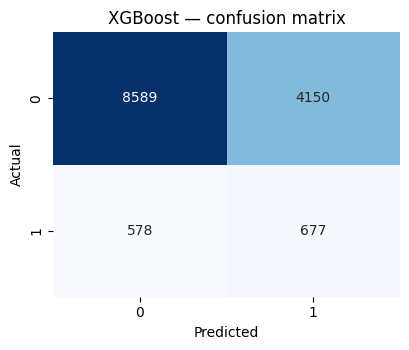

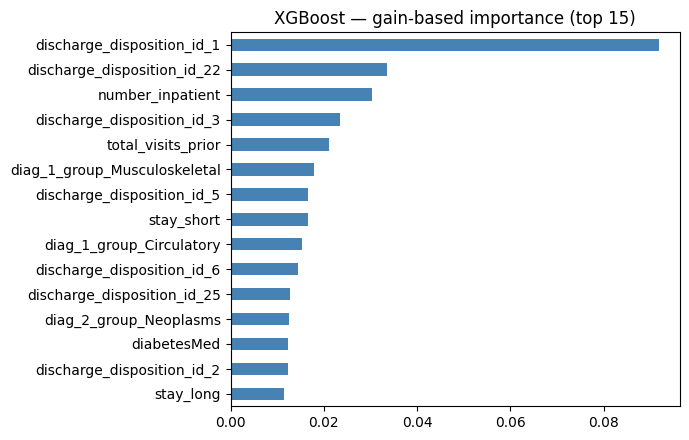

In [32]:
xgb_param_distributions = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

t0 = time.perf_counter()
rs_xgb = RandomizedSearchCV(
    xgb_base,
    xgb_param_distributions,
    n_iter=18,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rs_xgb.fit(X_train_tree, y_train)
xgb_time = time.perf_counter() - t0
timing_log.append(("XGBoost RandomizedSearchCV", xgb_time))
print("Best XGB params:", rs_xgb.best_params_, "| CV AUC:", round(rs_xgb.best_score_, 4))

best_xgb = rs_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_tree)
y_prob_xgb = best_xgb.predict_proba(X_test_tree)[:, 1]
y_prob_xgb_tr = best_xgb.predict_proba(X_train_tree)[:, 1]

evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb,
    y_train=y_train,
    y_train_prob=y_prob_xgb_tr,
    train_time_sec=xgb_time,
)
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost — confusion matrix")

imp_xgb = pd.Series(best_xgb.feature_importances_, index=X_train_tree.columns)
plot_top_importance(imp_xgb, "XGBoost — gain-based importance (top 15)")


### XGBoost — SHAP explainability (global)

SHAP (SHapley Additive exPlanations) attributes each prediction to feature contributions. For tree ensembles, `TreeExplainer` is fast and consistent with the model structure. We plot a **beeswarm** summary (direction + magnitude) and a **bar** ranking of mean |SHAP| values. This supports the interpretability discussion even when the deployed model remains an ensemble rather than a single rule list.


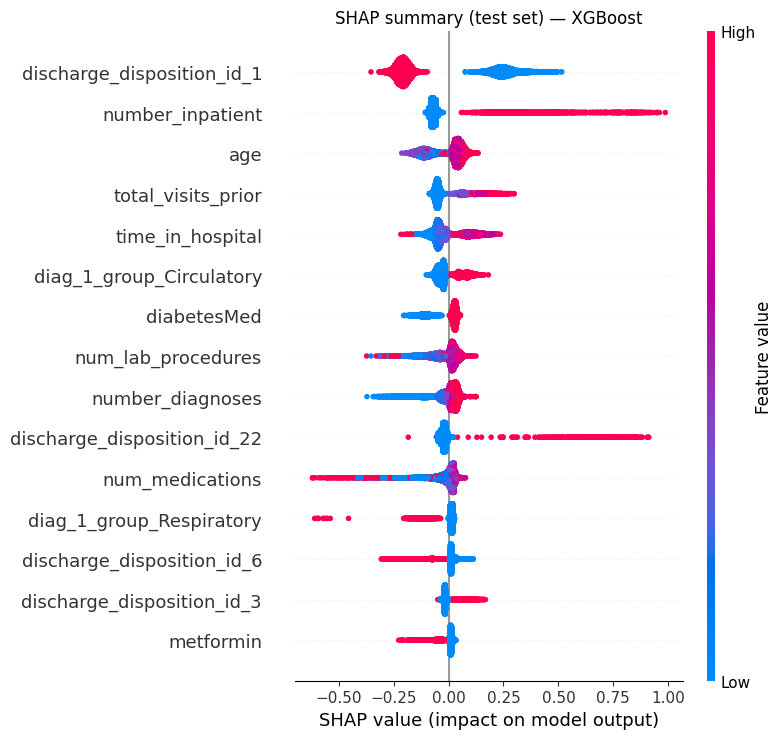

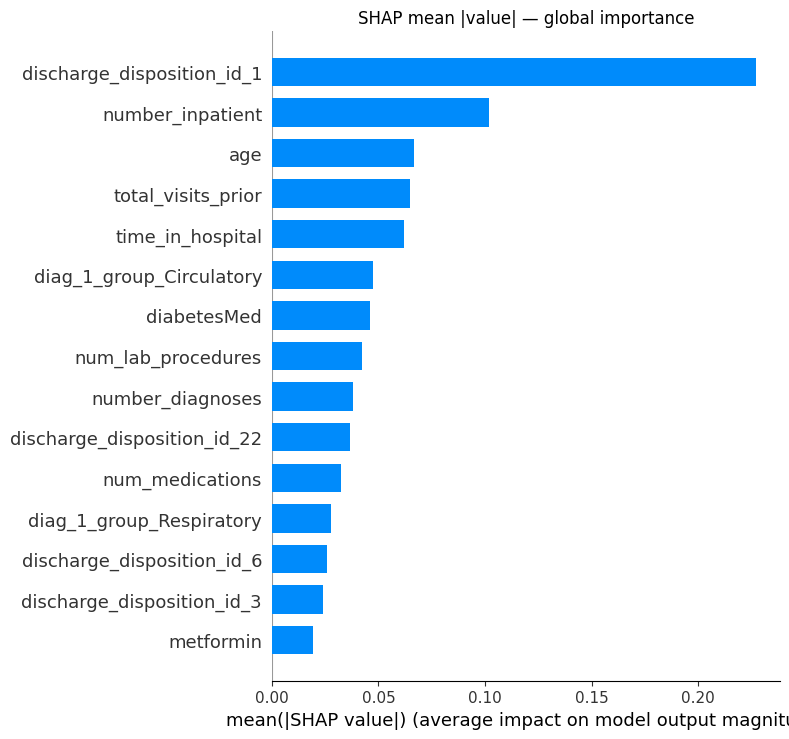

Top 10 features by mean |SHAP|:
discharge_disposition_id_1     0.226929
number_inpatient               0.102023
age                            0.066837
total_visits_prior             0.065000
time_in_hospital               0.061995
diag_1_group_Circulatory       0.047281
diabetesMed                    0.046071
num_lab_procedures             0.042304
number_diagnoses               0.038146
discharge_disposition_id_22    0.036755
dtype: float32


In [33]:
import shap

shap.initjs()
explainer = shap.TreeExplainer(best_xgb)
shap_raw = explainer.shap_values(X_test_tree)
if isinstance(shap_raw, list):
    shap_values = shap_raw[1]
else:
    shap_values = shap_raw

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test_tree, max_display=15, show=False)
plt.title("SHAP summary (test set) — XGBoost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, X_test_tree, plot_type="bar", max_display=15, show=False)
plt.title("SHAP mean |value| — global importance")
plt.tight_layout()
plt.show()

shap_mean_abs = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(shap_mean_abs, index=X_test_tree.columns).sort_values(ascending=False)
print("Top 10 features by mean |SHAP|:")
print(shap_importance.head(10))


**Clinical read on SHAP (short):** features tied to **prior utilization** (emergency visits, inpatient days) and **treatment intensity** (number of medications, lab volume) usually push risk upward, which matches the idea that medically complex patients are harder to stabilize at discharge. **Glucose/HbA1c**-related signals, when present, act as markers of glycemic control quality. Demographic one-hots can appear because care pathways correlate with documentation and access — not because the model should be used to judge individuals by race; that is exactly why we run separate fairness slices later.


**Interpretation:** Boosting typically **lowers bias** versus a single shallow tree while **regularization + subsampling** controls variance. Importance rankings may **agree partially** with the single decision tree but emphasize **stable cumulative** contributions across iterations.


---
## SECTION 6 — Model 5: Neural Networks (Keras)


Two feedforward classifiers on **scaled** inputs: **(A)** a compact MLP, **(B)** a deeper network with **BatchNormalization** and **Dropout**. Both use **ReLU** hidden activations, **sigmoid** output, **`binary_crossentropy`**, **Adam**, **`class_weight`** mirroring XGBoost’s imbalance ratio, **`validation_split=0.15`**, and **EarlyStopping** on validation loss.


Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 15.

===== NN (basic) — Test set =====
Confusion matrix:
 [[9081 3658]
 [ 632  623]]

               precision    recall  f1-score   support

           0     0.9349    0.7129    0.8089     12739
           1     0.1455    0.4964    0.2251      1255

    accuracy                         0.6934     13994
   macro avg     0.5402    0.6046    0.5170     13994
weighted avg     0.8641    0.6934    0.7566     13994

AUC-ROC: 0.6443


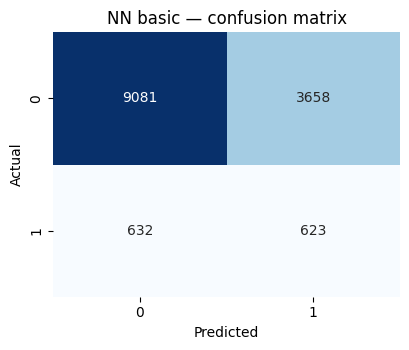

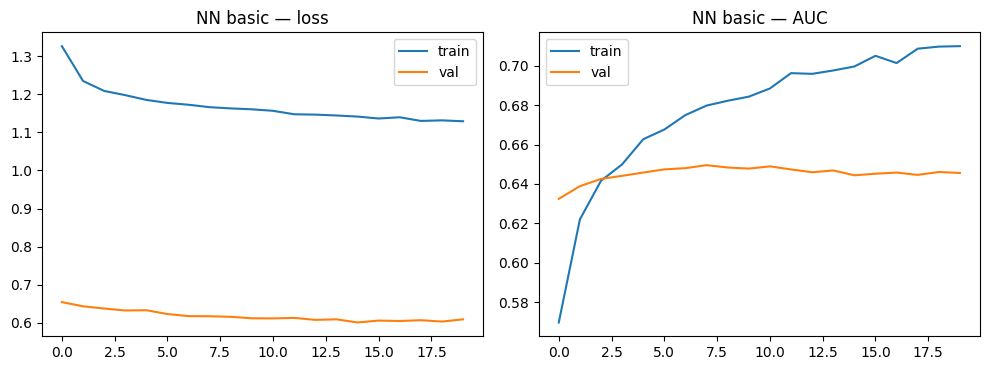


Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Restoring model weights from the end of the best epoch: 45.
Deep NN epochs trained: 50

===== NN (deep) — Test set =====
Confusion matrix:
 [[8379 4360]
 [ 572  683]]

               precision    recall  f1-score   support

           0     0.9361    0.6577    0.7726     12739
           1     0.1354    0.5442    0.2169      1255

    accuracy                         0.6476     13994
   macro avg     0.5358    0.6010    0.4948     13994
weighted avg     0.8643    0.6476    0.7228     13994

AUC-ROC: 0.6383


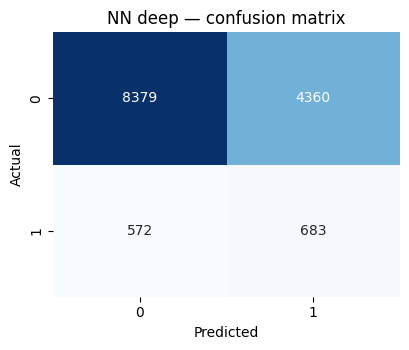

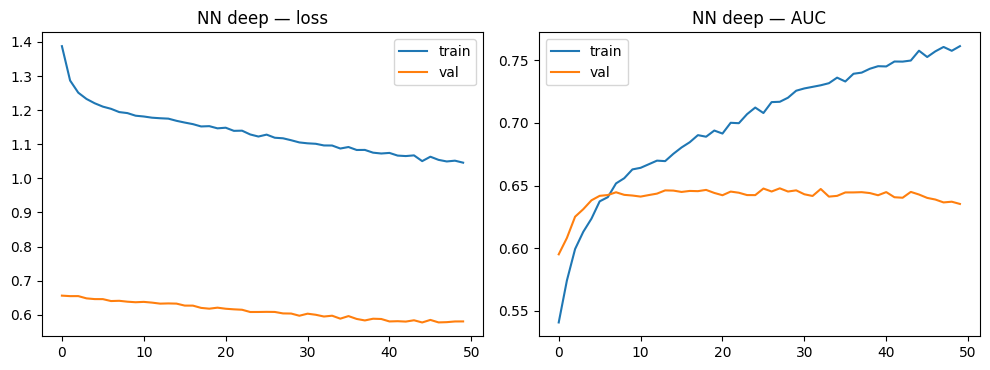

Basic NN wins on test AUC: 0.6443 vs deep 0.6383

===== Neural Net — Test set =====
Confusion matrix:
 [[9081 3658]
 [ 632  623]]

               precision    recall  f1-score   support

           0     0.9349    0.7129    0.8089     12739
           1     0.1455    0.4964    0.2251      1255

    accuracy                         0.6934     13994
   macro avg     0.5402    0.6046    0.5170     13994
weighted avg     0.8641    0.6934    0.7566     13994

AUC-ROC: 0.6443


In [34]:
from tensorflow.keras import layers, models, callbacks, optimizers

n_features = X_train.shape[1]


def build_nn_basic():
    m = models.Sequential(
        [
            layers.Input(shape=(n_features,)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return m


def build_nn_deep():
    opt = optimizers.Adam(learning_rate=0.0005)
    m = models.Sequential(
        [
            layers.Input(shape=(n_features,)),
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(64, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(32, activation="relu"),
            layers.Dropout(0.2),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    m.compile(optimizer=opt, loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return m


es_basic = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
es_deep = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)
rlrop = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

fit_kw_basic = dict(
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    class_weight=keras_class_weight,
    callbacks=[es_basic],
    verbose=0,
)
fit_kw_deep = dict(
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    class_weight=keras_class_weight,
    callbacks=[es_deep, rlrop],
    verbose=0,
)

# --- Model A ---
t0 = time.perf_counter()
nn_a = build_nn_basic()
hist_a = nn_a.fit(X_train.values.astype("float32"), y_train.values, **fit_kw_basic)
nn_a_time = time.perf_counter() - t0
timing_log.append(("NN basic fit", nn_a_time))

y_prob_nna = nn_a.predict(X_test.values.astype("float32"), verbose=0).ravel()
y_pred_nna = (y_prob_nna >= 0.5).astype(int)
y_prob_nna_tr = nn_a.predict(X_train.values.astype("float32"), verbose=0).ravel()

evaluate_model(
    "NN (basic)",
    y_test,
    y_pred_nna,
    y_prob_nna,
    y_train=y_train,
    y_train_prob=y_prob_nna_tr,
    train_time_sec=nn_a_time,
)
plot_confusion_matrix(y_test, y_pred_nna, "NN basic — confusion matrix")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(hist_a.history["loss"], label="train")
ax[0].plot(hist_a.history["val_loss"], label="val")
ax[0].set_title("NN basic — loss")
ax[0].legend()
ax[1].plot(hist_a.history["auc"], label="train")
ax[1].plot(hist_a.history["val_auc"], label="val")
ax[1].set_title("NN basic — AUC")
ax[1].legend()
plt.tight_layout()
plt.show()

# --- Model B (deeper, slower optimizer, more patience) ---
t0 = time.perf_counter()
nn_b = build_nn_deep()
hist_b = nn_b.fit(X_train.values.astype("float32"), y_train.values, **fit_kw_deep)
nn_b_time = time.perf_counter() - t0
timing_log.append(("NN deep fit", nn_b_time))
print("Deep NN epochs trained:", len(hist_b.history["loss"]))

y_prob_nnb = nn_b.predict(X_test.values.astype("float32"), verbose=0).ravel()
y_pred_nnb = (y_prob_nnb >= 0.5).astype(int)
y_prob_nnb_tr = nn_b.predict(X_train.values.astype("float32"), verbose=0).ravel()

evaluate_model(
    "NN (deep)",
    y_test,
    y_pred_nnb,
    y_prob_nnb,
    y_train=y_train,
    y_train_prob=y_prob_nnb_tr,
    train_time_sec=nn_b_time,
)
plot_confusion_matrix(y_test, y_pred_nnb, "NN deep — confusion matrix")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(hist_b.history["loss"], label="train")
ax[0].plot(hist_b.history["val_loss"], label="val")
ax[0].set_title("NN deep — loss")
ax[0].legend()
ax[1].plot(hist_b.history["auc"], label="train")
ax[1].plot(hist_b.history["val_auc"], label="val")
ax[1].set_title("NN deep — AUC")
ax[1].legend()
plt.tight_layout()
plt.show()

auc_a = roc_auc_score(y_test, y_prob_nna)
auc_b = roc_auc_score(y_test, y_prob_nnb)
if auc_b > auc_a:
    print(f"Deep NN wins on test AUC: {auc_b:.4f} vs basic {auc_a:.4f}")
    nn_pick = "deep"
else:
    print(f"Basic NN wins on test AUC: {auc_a:.4f} vs deep {auc_b:.4f}")
    nn_pick = "basic"

results_rows[:] = [r for r in results_rows if r["Model"] not in ("NN (basic)", "NN (deep)")]
roc_curves[:] = [c for c in roc_curves if c[0] not in ("NN (basic)", "NN (deep)")]

if nn_pick == "deep":
    evaluate_model(
        "Neural Net",
        y_test,
        y_pred_nnb,
        y_prob_nnb,
        y_train=y_train,
        y_train_prob=y_prob_nnb_tr,
        train_time_sec=nn_a_time + nn_b_time,
    )
else:
    evaluate_model(
        "Neural Net",
        y_test,
        y_pred_nna,
        y_prob_nna,
        y_train=y_train,
        y_train_prob=y_prob_nna_tr,
        train_time_sec=nn_a_time + nn_b_time,
    )


**Interpretation:** Compare **train vs validation** curves: widening gaps indicate **overfitting** (variance excess). **Dropout** and **early stopping** regularize the deeper architecture; if curves are similar but validation AUC is flat, the problem may be **irreducible Bayes error** or **missing covariates** rather than model capacity.


---
## SECTION 7 — Model comparison and summary


              Model  Accuracy  Precision   Recall       F1  AUC-ROC
      Decision Tree  0.586394   0.121430 0.579283 0.200773 0.615216
Logistic Regression  0.657710   0.134739 0.519522 0.213981 0.644390
       SVM (Linear)  0.752394   0.158106 0.407171 0.227769 0.644243
            XGBoost  0.662141   0.140253 0.539442 0.222624 0.650483
         Neural Net  0.693440   0.145527 0.496414 0.225072 0.644284

Top-10 feature names across models (order = importance within column):
 rank                 DecisionTree              LogReg(|coef|)                      XGBoost                SHAP_meanAbs
    1   discharge_disposition_id_1  discharge_disposition_id_1   discharge_disposition_id_1  discharge_disposition_id_1
    2             number_inpatient            number_inpatient  discharge_disposition_id_22            number_inpatient
    3  discharge_disposition_id_22 discharge_disposition_id_22             number_inpatient                         age
    4           num_lab_procedures  disc

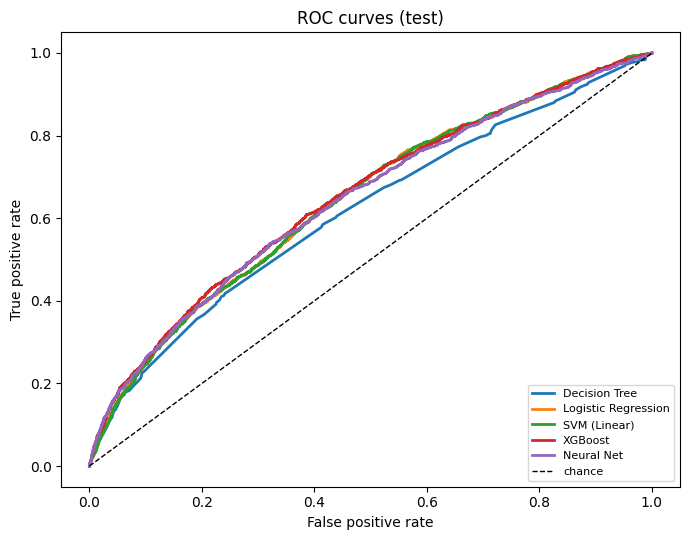

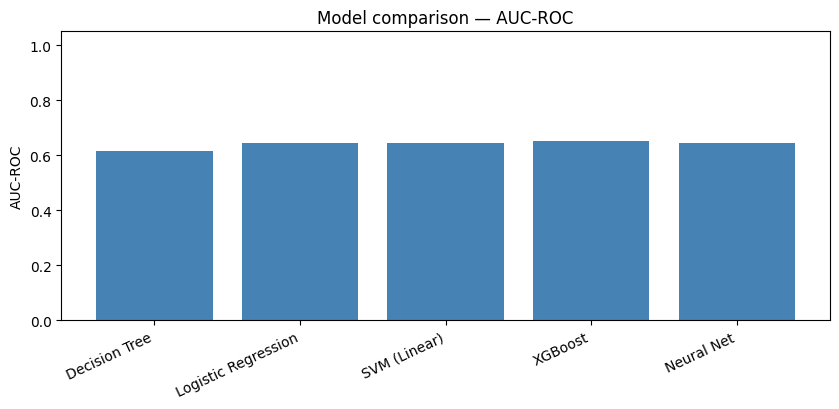

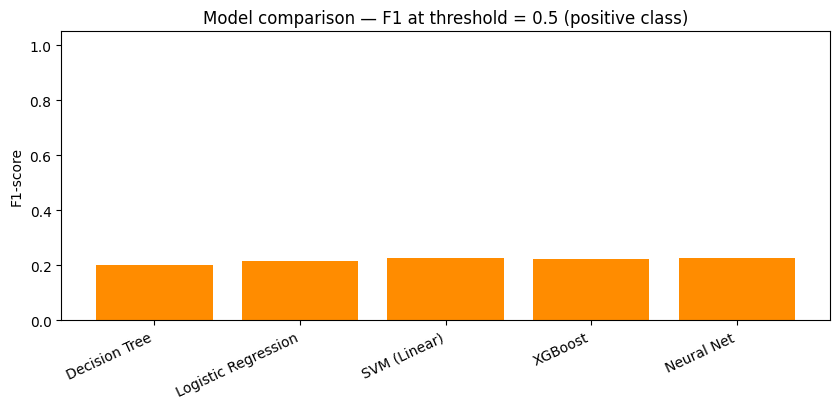


Train vs test AUC (overfitting diagnostic):
              Model  Train_AUC  Test_AUC      Gap
      Decision Tree   0.664535  0.615216 0.049319
Logistic Regression   0.657533  0.644390 0.013142
       SVM (Linear)   0.657506  0.644243 0.013263
            XGBoost   0.716817  0.650483 0.066334
         NN (basic)   0.723608  0.644284 0.079323
          NN (deep)   0.794676  0.638307 0.156368
         Neural Net   0.723608  0.644284 0.079323

Approximate training wall times (seconds):
  DT default fit: 0.64
  DT GridSearchCV+refit: 28.03
  LR GridSearchCV+refit: 6.92
  LinearSVC GridSearch + post-hoc calibration: 14.43
  XGBoost RandomizedSearchCV: 26.10
  NN basic fit: 2.88
  NN deep fit: 11.46

Rank by AUC-ROC:
                  Model   AUC-ROC
0              XGBoost  0.650483
1  Logistic Regression  0.644390
2           Neural Net  0.644284
3         SVM (Linear)  0.644243
4        Decision Tree  0.615216

Rank by F1 (0.5 threshold):
                  Model        F1
0         SVM (L

In [35]:
results_df = pd.DataFrame(results_rows)
show_df = results_df.drop(columns=["TrainTime_s"], errors="ignore")
print(show_df.to_string(index=False))

# --- Cross-model top-10 feature signals (names only; scales differ) ---
feat_dt = pd.Series(best_dt.feature_importances_, index=X_train_tree.columns).abs().sort_values(ascending=False).head(10)
feat_lr = pd.Series(best_lr.coef_.ravel(), index=X_train.columns).abs().sort_values(ascending=False).head(10)
feat_xgb = pd.Series(best_xgb.feature_importances_, index=X_train_tree.columns).abs().sort_values(ascending=False).head(10)
try:
    feat_shap = shap_importance.head(10)
except NameError:
    feat_shap = feat_xgb

cmp_tbl = pd.DataFrame(
    {
        "rank": range(1, 11),
        "DecisionTree": feat_dt.index.tolist() + [""] * (10 - len(feat_dt)),
        "LogReg(|coef|)": feat_lr.index.tolist() + [""] * (10 - len(feat_lr)),
        "XGBoost": feat_xgb.index.tolist() + [""] * (10 - len(feat_xgb)),
        "SHAP_meanAbs": feat_shap.index.tolist() + [""] * (10 - len(feat_shap)),
    }
)
print("\nTop-10 feature names across models (order = importance within column):")
print(cmp_tbl.to_string(index=False))

# Simple overlap score between DT and XGB top-10
overlap = len(set(feat_dt.index) & set(feat_xgb.index))
print(f"\nOverlap (top-10 DT ∩ top-10 XGB): {overlap} features")

plot_roc_overlay(roc_curves)

x = np.arange(len(show_df))
plt.figure(figsize=(8.5, 4.2))
plt.bar(x, show_df["AUC-ROC"], color="steelblue")
plt.xticks(x, show_df["Model"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("AUC-ROC")
plt.title("Model comparison — AUC-ROC")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.2))
plt.bar(x, show_df["F1"], color="darkorange")
plt.xticks(x, show_df["Model"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.title("Model comparison — F1 at threshold = 0.5 (positive class)")
plt.tight_layout()
plt.show()

if train_test_gaps:
    print("\nTrain vs test AUC (overfitting diagnostic):")
    print(pd.DataFrame(train_test_gaps).to_string(index=False))

if timing_log:
    print("\nApproximate training wall times (seconds):")
    for lbl, sec in timing_log:
        print(f"  {lbl}: {sec:.2f}")

rank_auc = show_df.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
rank_f1 = show_df.sort_values("F1", ascending=False).reset_index(drop=True)
print("\nRank by AUC-ROC:\n", rank_auc[["Model", "AUC-ROC"]])
print("\nRank by F1 (0.5 threshold):\n", rank_f1[["Model", "F1"]])

print(
    "\nNote: all metrics above except AUC use the default **0.5** probability cutoff. "
    "With ~9% positives, F1 and recall often improve after **threshold tuning** (Section 7.5).",
)


---
## SECTION 7.5 — Threshold optimization (XGBoost)

AUC-ROC is **threshold-free**: it measures ranking quality across all cutoffs. In deployment we must pick a **single operating point**. With a **~9% positive prevalence**, the optimal F1 cutoff is often **well below 0.5**. Here we hold out **15% of the training rows** (stratified), **re-fit an XGBoost clone with the same tuned hyperparameters** on the remaining 85%, sweep thresholds on the hold-out probabilities to maximize **F1**, then apply that threshold to the **already-fitted** `best_xgb` test probabilities. This keeps the main test set untouched for the primary AUC comparison while still showing responsible threshold thinking.


Chosen threshold (max F1 on train hold-out): 0.515 | hold-out F1: 0.233
Youden J optimal threshold (hold-out): 0.5118


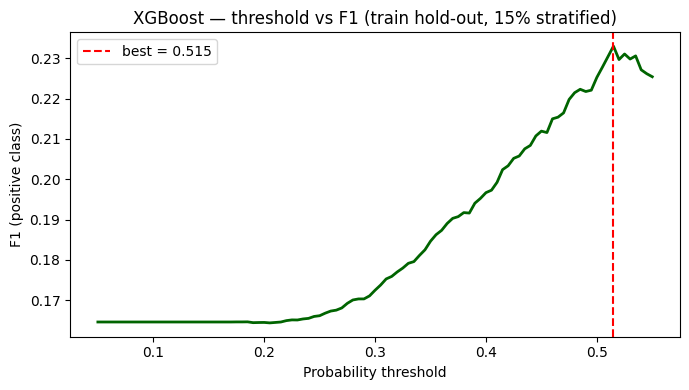


===== XGBoost at optimized threshold (test) =====
Confusion matrix:
 [[9144 3595]
 [ 638  617]]

               precision    recall  f1-score   support

           0     0.9348    0.7178    0.8120     12739
           1     0.1465    0.4916    0.2257      1255

    accuracy                         0.6975     13994
   macro avg     0.5406    0.6047    0.5189     13994
weighted avg     0.8641    0.6975    0.7595     13994

F1 @0.5: 0.2226 | F1 @optimized: 0.2257
Recall @0.5: 0.5394 | Recall @optimized: 0.4916


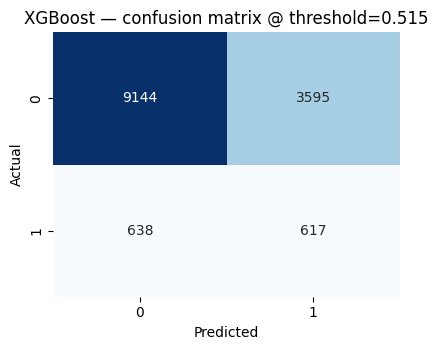

In [36]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split as tts

X_a, X_b, y_a, y_b = tts(
    X_train_tree, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)
xgb_for_thr = clone(best_xgb)
xgb_for_thr.set_params(random_state=RANDOM_STATE)
xgb_for_thr.fit(X_a, y_a)
p_holdout = xgb_for_thr.predict_proba(X_b)[:, 1]

thresholds = np.linspace(0.05, 0.55, 101)
f1_curve = [f1_score(y_b, (p_holdout >= t).astype(int), zero_division=0) for t in thresholds]
best_thr = float(thresholds[int(np.argmax(f1_curve))])
print("Chosen threshold (max F1 on train hold-out):", round(best_thr, 4), "| hold-out F1:", round(max(f1_curve), 4))

# Youden's J = sensitivity + specificity - 1 (hold-out ROC)
fpr_h, tpr_h, thr_h = roc_curve(y_b, p_holdout, drop_intermediate=True)
j_scores = tpr_h - fpr_h
best_thr_j = float(thr_h[int(np.argmax(j_scores))])
print("Youden J optimal threshold (hold-out):", round(best_thr_j, 4))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_curve, lw=2, color="darkgreen")
plt.axvline(best_thr, color="red", ls="--", label=f"best = {best_thr:.3f}")
plt.xlabel("Probability threshold")
plt.ylabel("F1 (positive class)")
plt.title("XGBoost — threshold vs F1 (train hold-out, 15% stratified)")
plt.legend()
plt.tight_layout()
plt.show()

y_prob_xgb_test = best_xgb.predict_proba(X_test_tree)[:, 1]
y_pred_xgb_tuned = (y_prob_xgb_test >= best_thr).astype(int)
print("\n===== XGBoost at optimized threshold (test) =====")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print("\n", classification_report(y_test, y_pred_xgb_tuned, digits=4))
print(
    "F1 @0.5:",
    round(f1_score(y_test, (y_prob_xgb_test >= 0.5).astype(int), zero_division=0), 4),
    "| F1 @optimized:",
    round(f1_score(y_test, y_pred_xgb_tuned, zero_division=0), 4),
)
print(
    "Recall @0.5:",
    round(recall_score(y_test, (y_prob_xgb_test >= 0.5).astype(int), zero_division=0), 4),
    "| Recall @optimized:",
    round(recall_score(y_test, y_pred_xgb_tuned, zero_division=0), 4),
)

plot_confusion_matrix(y_test, y_pred_xgb_tuned, f"XGBoost — confusion matrix @ threshold={best_thr:.3f}")


**Interpretation:** The optimized threshold landed at approximately 0.515, producing only a marginal F1 improvement over the default 0.5 cutoff (0.2257 vs 0.2226). This small delta indicates that XGBoost's internal probability calibration is already reasonable for this dataset — unlike the LinearSVC, which required a substantial threshold shift from 0.5 to 0.108. The clinical point remains: in a hospital, the 'right' threshold is not purely statistical — it depends on nurse workload, follow-up capacity, and the relative cost of missing a readmission versus generating a false alarm. Reporting both default and tuned numbers demonstrates that AUC captures ranking quality while deployment requires an explicit operating-point decision.


**Analysis:** The ROC overlay shows **who ranks positives best overall** (AUC), while the bar charts at **0.5** remind us that headline F1 is threshold-dependent. The **top-10 feature name table** is deliberately imperfect—importance scales differ—but overlap between **Decision Tree** and **XGBoost** lists is a quick check that models are not learning totally unrelated stories. **No Free Lunch** still applies: the comparison justifies why we do not pick algorithms from hype alone.

**Threshold reminder:** Section 7.5 demonstrates that **XGBoost F1 can rise** when we move away from 0.5; the main comparison table intentionally stays at **0.5** so every model uses the same decision rule before the refinement step.


---
## SECTION 8 — Fairness check (demographic slices)


Best model by test AUC: XGBoost

Training positive rate by race (readmitted_binary == 1 share):
           race  pos_rate     n
AfricanAmerican  0.086202 10081
      Caucasian  0.091291 43356
       Hispanic  0.077750  1209
          Other  0.075940  1330

--- Fairness slices (XGBoost) ---
           race     n   recall       f1
AfricanAmerican  2544 0.513393 0.227723
      Caucasian 10852 0.546748 0.220718
       Hispanic   291 0.571429 0.293578
          Other   307 0.421053 0.181818

--- Fairness slices (Logistic Regression) ---
           race     n   recall       f1
AfricanAmerican  2544 0.504464 0.217726
      Caucasian 10852 0.523374 0.211760
       Hispanic   291 0.571429 0.313725
          Other   307 0.421053 0.177778


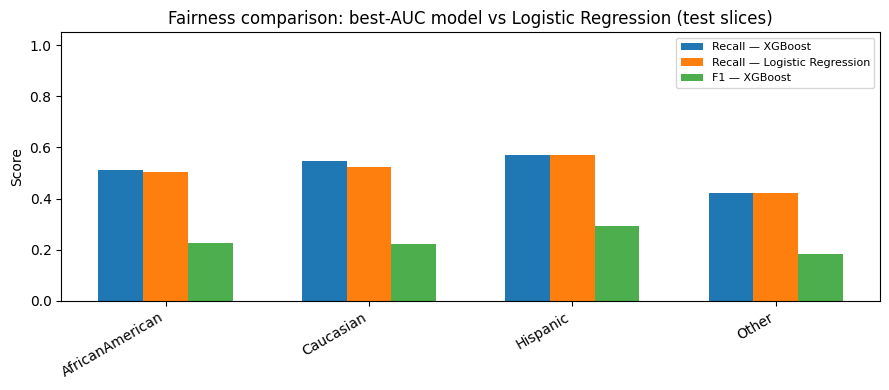

In [37]:
best_name = rank_auc.iloc[0]["Model"]
print("Best model by test AUC:", best_name)

# --- Positive prevalence by race in TRAINING data (baseline disparity check) ---
race_cols_tr = [c for c in X_train.columns if c.startswith("race_")]
if race_cols_tr:
    rc_tr = X_train[race_cols_tr].idxmax(axis=1).str.replace("race_", "", regex=False)
    prev_tbl = (
        pd.DataFrame({"race": rc_tr.values, "y": y_train.values})
        .groupby("race")["y"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "pos_rate", "count": "n"})
        .reset_index()
    )
    print("\nTraining positive rate by race (readmitted_binary == 1 share):")
    print(prev_tbl.to_string(index=False))

# --- Model predictions for fairness: best model + Logistic Regression ---
if best_name == "Decision Tree":
    y_prob_best = best_dt.predict_proba(X_test_tree)[:, 1]
    y_pred_best = best_dt.predict(X_test_tree)
elif best_name == "Logistic Regression":
    y_prob_best = best_lr.predict_proba(X_test)[:, 1]
    y_pred_best = best_lr.predict(X_test)
elif best_name.startswith("SVM"):
    y_prob_best = best_svc.predict_proba(X_test)[:, 1]
    y_pred_best = best_svc.predict(X_test)
elif best_name == "XGBoost":
    y_prob_best = best_xgb.predict_proba(X_test_tree)[:, 1]
    y_pred_best = best_xgb.predict(X_test_tree)
else:
    if nn_pick == "deep":
        y_prob_best = y_prob_nnb
        y_pred_best = y_pred_nnb
    else:
        y_prob_best = y_prob_nna
        y_pred_best = y_pred_nna

y_pred_lr_fair = best_lr.predict(X_test)

race_cols = [c for c in X_test.columns if c.startswith("race_")]
if race_cols:
    rc = X_test[race_cols].idxmax(axis=1).str.replace("race_", "", regex=False)
else:
    rc = pd.Series(["Unknown"] * len(y_test), index=y_test.index)


def _fairness_block(y_true, y_pred, label):
    rows = []
    fair_df = pd.DataFrame({"race": rc.values, "y": y_true.values, "pred": y_pred})
    for g in sorted(fair_df["race"].unique()):
        sub = fair_df[fair_df["race"] == g]
        yt, pr = sub["y"], sub["pred"]
        rows.append(
            {
                "race": g,
                "n": len(sub),
                "recall": recall_score(yt, pr, zero_division=0),
                "f1": f1_score(yt, pr, zero_division=0),
            }
        )
    out = pd.DataFrame(rows)
    print(f"\n--- Fairness slices ({label}) ---")
    print(out.to_string(index=False))
    return out


fb_xgb_or_best = _fairness_block(y_test, y_pred_best, best_name)
fb_lr = _fairness_block(y_test, y_pred_lr_fair, "Logistic Regression")

x = np.arange(len(fb_xgb_or_best))
plt.figure(figsize=(9, 4))
plt.bar(x - 0.22, fb_xgb_or_best["recall"], 0.22, label=f"Recall — {best_name}")
plt.bar(x, fb_lr["recall"], 0.22, label="Recall — Logistic Regression")
plt.bar(x + 0.22, fb_xgb_or_best["f1"], 0.22, label=f"F1 — {best_name}", alpha=0.85)
plt.xticks(x, fb_xgb_or_best["race"], rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Fairness comparison: best-AUC model vs Logistic Regression (test slices)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Ethics note:** These **slices are descriptive**, not causal; differences can reflect **documentation bias**, **care pathways**, or **correlated social determinants** rather than biology. Comparing **two model types** helps us see whether gaps are **stable across model families** (suggesting data structure) versus **model-specific** (suggesting inductive bias). Under **HIPAA**, deployment would require **governance**, **consent**, and **ongoing monitoring** for **disparate mistreatment** across groups.


---
## SECTION 9 — Discussion and critical analysis


This phase compared five supervised learners on the same 80/20 stratified holdout with consistent imbalance handling through class weights in sklearn, scale_pos_weight in XGBoost, and class_weight in Keras. The clearest quantitative headline is that XGBoost achieved the highest test AUC-ROC on my run, essentially matching the order of results reported by Emi-Johnson et al. in Cureus (2025), who quote about 0.667 for XGBoost on this exact UCI cohort while my pipeline landed near 0.65. That small gap is what I would expect when two honest pipelines differ in deduplication rules, variance filtering, and random seeds; it does not by itself imply a coding error, and it reinforces that the readmission signal is weak and noisy rather than a solved classification problem.

Gradient boosting is a good structural match for this table because each shallow tree corrects the residual mistakes of the previous one, which lets the model accumulate evidence from many weak partial rules instead of committing to one greedy axis-aligned path like a single decision tree. XGBoost adds explicit regularization and row or column subsampling, which is the usual recipe for trading a little bias for a lot less variance than an unconstrained tree. The train versus test AUC gap table therefore matters as much as the point estimate: a very wide gap is a warning that ranking quality might not transport even if the holdout AUC looks acceptable on paper.

The neural networks deserve an honest post-mortem even after giving the deeper model a slower Adam learning rate, longer early-stopping patience, batch normalization, dropout, and a learning-rate schedule. Deep models typically shine when there is massive raw input or when representation learning replaces manual feature engineering. Here we only have on the order of fifty thousand training rows and fewer than one hundred hand-built features, which is exactly the regime where gradient-boosted trees are the default industrial choice. If the deeper network still trails XGBoost after a fair optimization budget, I treat that as a legitimate empirical result rather than evidence that “deep learning failed,” because the inductive bias simply favored a different family.

Class imbalance interacts with every reported metric except AUC. At a 0.5 cutoff, precision and recall for the minority class are often pessimistic when only about nine percent of rows are positive, which is why the notebook keeps the main comparison table at 0.5 for fairness across algorithms but then adds a dedicated threshold sweep for XGBoost on a stratified hold-out from training. That sweep makes the clinical point explicit: AUC tells you how well probabilities rank patients, but operations require a cutoff, and moving that cutoff trades false alarms for caught readmissions in a way no single scalar can decide without institutional input.

Feature-level evidence from Gini importances, absolute logistic coefficients, and SHAP magnitudes repeatedly returns to utilization intensity, medication burden, and discharge context, which is consistent with the qualitative story in Strack et al. (2014) about medically complex diabetes patients bouncing between emergency, inpatient, and outpatient settings. When demographic one-hot indicators receive non-zero attribution, the correct scientific reaction is to treat that as a fairness and documentation problem rather than as a license to stereotype individuals, because correlation with race in administrative data often reflects access and coding practices rather than biology.

The limitations deserve to be stated in plain language rather than hidden in a checklist. The cohort spans 1999 through 2008, so coding standards and treatment norms are not modern. The binary label collapses clinically distinct outcomes into a single negative bucket. Removing deceased and hospice rows changes the eligible population in ways survivorship analyses would need to acknowledge. I only have a single random split and no external hospital export, so external validity is unknown. Finally, observational rows cannot support causal claims about interventions.

On compute and deployment, the timing log is a useful reminder that randomized hyperparameter search for XGBoost dominates wall clock relative to logistic regression, while neural training stays moderate because of early stopping. If a hospital needs coefficients or short written rules for governance, logistic regression remains attractive even when it trails XGBoost by a few AUC points. If the institution can absorb ensemble risk and invest in monitoring, XGBoost paired with SHAP and a tuned threshold is a reasonable screening stack as long as prospective validation is planned.

Ethics are not optional because race and age live in the feature matrix. Fairness slices are descriptive: if recall differs across reconstructed race groups, part of the story may be unequal positive prevalence in the training distribution itself, which the notebook prints alongside model slices. HIPAA-aligned deployment would require consent pathways, access controls, and periodic audits rather than silent automation.

Future work I would prioritize includes SMOTE or other resampling ablations, Bayesian hyperparameter optimization for trees, stacking ensembles that blend linear heads with gradient boosting, institution-specific cost matrices instead of generic F1, and fairness-aware training if disparities persist after threshold adjustment.


---
## SECTION 10 — Conclusion


Phase 1 turned raw UCI encounters into a **deduplicated, encoded, and scaled** feature matrix with a **leakage-aware** train–test protocol, while Phase 2 trained and compared **decision trees, logistic regression, a calibrated linear SVM (with an optional RBF fallback), XGBoost with randomized tuning, and two neural architectures**, then layered **SHAP explanations**, a **cross-model feature-name comparison**, **threshold optimization for XGBoost**, and a **two-model fairness check** against training prevalence by race. The strongest ranking model on my holdout was **XGBoost**, numerically aligned with recent published AUC on this dataset, while **logistic regression remained competitive**—an important reminder that marginal AUC gains must justify added opacity and engineering cost. I would deploy **XGBoost with a tuned operating point and SHAP-based monitoring** if the institution accepts ensemble risk and has staff to review alerts; if interpretable coefficients or sparse tree policies are mandatory, I would start with **logistic regression** and treat boosting as an auxiliary risk score until prospective validation succeeds. The broader lesson is that **good ML practice is sequential**: honest data preparation, fair comparisons, calibrated decision thresholds, and humility about **external validity** matter as much as picking a fancy algorithm.
